In [2]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

# Convoluce

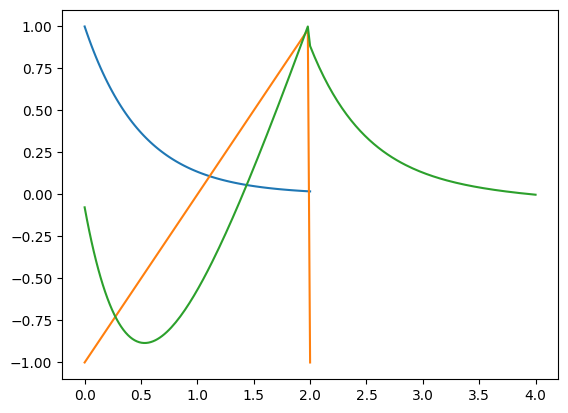

In [11]:


def Kernel(alpha, tvec,a):
    h_t = alpha*np.exp(-a*tvec)
    return np.array(h_t)

nlen = 100
tvec = np.linspace(0,2,nlen, endpoint=True)
h_t = Kernel(1.0, tvec, 2.0)
par = 2*np.pi*0.5*tvec
x_t = signal.square(par)
x_s = signal.sawtooth(par)
x_tt = np.where(tvec >= 1.0,0,x_t)

conv = np.convolve(x_s,h_t,mode='full')
conv = conv/np.max(conv)
t_conv = np.linspace(0,4,np.max(conv.shape))
plt.plot(tvec, h_t,label="h_t")
plt.plot(tvec, x_s,label="x_t")
plt.plot(t_conv, conv,label="conv")
plt.show()


# Kovariance

[[ 1.3337334  -0.02742777]
 [-0.02742777  1.00009901]]
-0.027425022502250228


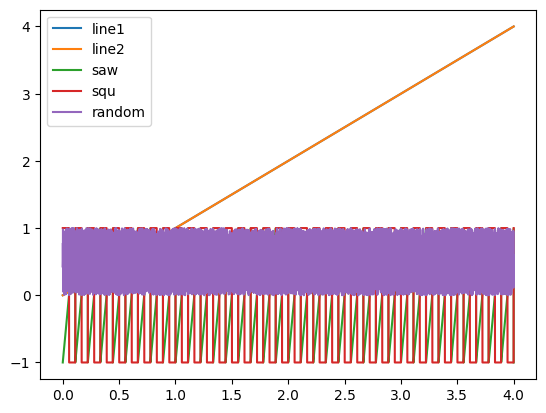

In [61]:
minf = 0
maxf = 4
steps = 10000
t_vec = np.linspace(minf, maxf, steps)

def line(a,x,b):
    return np.array(a*x + b)


def medium(l):
    res = np.mean(l)
    return np.array(res)


def covariance(l1, l2):
    med1 = medium(line1)
    med2 = medium(line3)
    res = 1/(len(l1))*np.sum((l1-med1)*(l2-med2))
    return np.array(res)


a = 1
b = 0
par = 6*np.pi*3*t_vec
line1 = line(a,t_vec,b)
line2 = line(a,t_vec,b)
line3 = signal.sawtooth(par)
line4 = signal.square(par)
line5 = np.random.rand(steps)

cov = covariance(line1,line4)
print(np.cov(line1,line4))
print(cov)
plt.plot(t_vec,line1,label="line1")
plt.plot(t_vec,line2,label="line2")
plt.plot(t_vec,line3,label="saw")
plt.plot(t_vec,line4,label="squ")
plt.plot(t_vec,line5,label="random")
plt.legend()
plt.show()

# Šum v signálu

[-0.09876302 -0.01777588  0.04444063 -0.20183409 -0.11689723 -0.00186686
  0.11032491  0.25666275  0.17415735  0.223055    0.29259511  0.2363268
  0.07483128 -0.0328651   0.19807041  0.2620611   0.00749116  0.12387213
  0.26733311  0.38007846  0.29298952  0.58272582  0.1927052   0.57510675
  0.4351893   0.03336326  0.49841395  0.20416297  0.30308985  0.39849276
  0.33058553  0.46573388  0.50661112  0.12619915  0.35246623  0.45972079
  0.50751109  0.32747035  0.4188435   0.41143148  0.32866822  0.47753909
  0.55801064  0.65817333  0.4506478   0.54409708  0.54678159  0.53754218
  0.44736878  0.63884175  0.71945464  0.57179397  0.54148971  0.50586905
  0.74615977  0.76442279  0.29378597  0.48130024  0.47393779  0.84112721
  0.6836413   0.72969225  0.7959585   0.9375274   0.59624682  0.66230361
  0.67449719  0.60782614  0.71845784  0.83025335  0.54047178  0.7818257
  0.79288462  1.10745621  0.56145128  0.86189237  0.88836572  0.61779294
  0.73548743  0.84249249  1.1050373   0.91706519  0.8

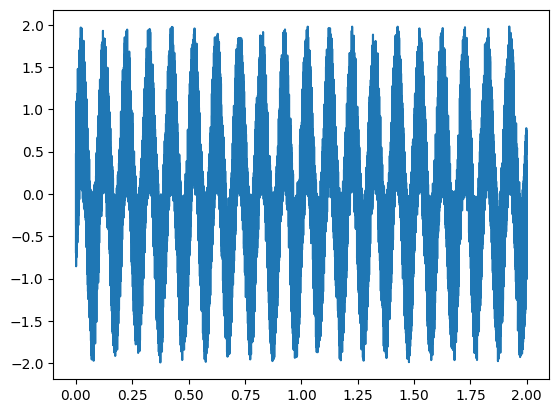

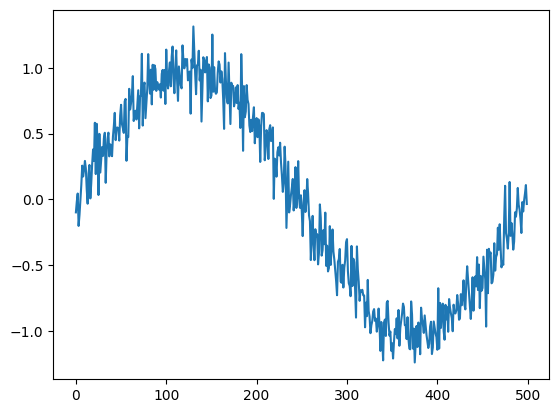

In [13]:
steps = 10000
a = 1
f = 10
numT = 20
T=1/f
Tmax = numT*T
t_v = np.linspace(0, Tmax, steps)

def sinefu(f, t_v):
    w = (2 * np.pi * f)
    res = np.sin(w*t_v)
    return np.array(res)

def garbage(a,t_v):
    res = a*(2*np.random.rand(t_v.size)-1)
    return np.array(res)

fun = sinefu(f,t_v)
fungar = garbage(a,t_v)
combo = np.array(fun+fungar)

period = int(steps/numT)
periods = np.reshape(combo,[numT,period])
avsig = np.sum(periods,axis=0)
avsig /= numT
print(avsig)
plt.plot(t_v, combo)
plt.show()
plt.plot(avsig)
plt.show()

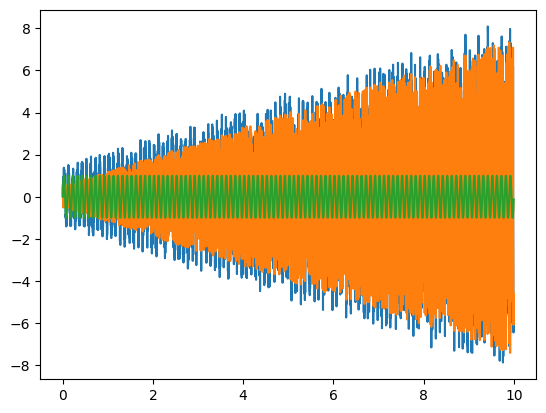

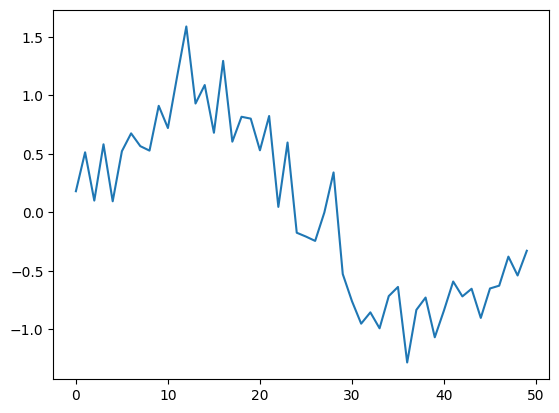

In [69]:
n_lenght = 5000
Amp = 0.5
numT = 100
f=10
A0 = 1.0
T=1/f
Tmax=numT*T
tvec = np.linspace(0,Tmax,n_lenght,endpoint=False)

def Kernel(alpha, tvec,a):
    h_t = alpha*np.exp(-a*tvec)
    return np.array(h_t)

def Fun_Increse(Amp, tvec):
    Ampvals = np.linspace(Amp,Amp*15,tvec.size)
    res = Ampvals*(2*np.random.rand(tvec.size)-1)
    return np.array(res)

def Sinefu(f, t_v):
    w = (2 * np.pi * f)
    res = np.sin(w*t_v)
    return np.array(res)

clear = Sinefu(f,tvec)
incresed = Fun_Increse(Amp,tvec)
destroyed = clear + incresed
plt.plot(tvec,destroyed,label='znicenej')
plt.plot(tvec,incresed)
plt.plot(tvec,clear)
plt.show()


period=int(n_lenght/numT)
periods = np.reshape(destroyed,[numT,period])
periods=np.sum(periods,axis=0)
periods /= numT
plt.plot(periods)
plt.show()

# Seminarni prace